## The core idea of AdaBoost (Adaptive Boosting) is to combine multiple weak learners into a strong learner by focusing on the mistakes of previous models.

# basic termiologies


weak leaners - ml model whose accuracy is around 50 %

Decision Stump - A Decision Stump is a very simple decision tree that consists of only one split — meaning it has just one internal
node and two leaves.

## weights in descision tree 
<img src='https://i.ibb.co/PvJR3GPp/image.png'>

<img src='../../../images/adaboost (1).png'>
<img src='../../../images/adaboost (2).png'>

after that we do upsmapling ( basically increase no of points that are incorrect )

for upsampling we need to create range - 

    upper_range=cumulative sum of row_weights
    lower_range= upper_range- row_weights

    now we generate n random no where n is no of rows between 0 and 1

    and update our X and y by selecting those rows between whom the random no is 

## learner weight function graph

this function give high values when error near 0 or near 1 it means that when error is 0 we know that our model is correct and when it give negative we know its opposite is correct it give 0 at 0.5 which means we are guessing with a probab of 50% 

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

C:\Users\panka\AppData\Local\Temp\ipykernel_23216\724252321.py:3: RuntimeWarning:

divide by zero encountered in divide

C:\Users\panka\AppData\Local\Temp\ipykernel_23216\724252321.py:3: RuntimeWarning:

divide by zero encountered in log



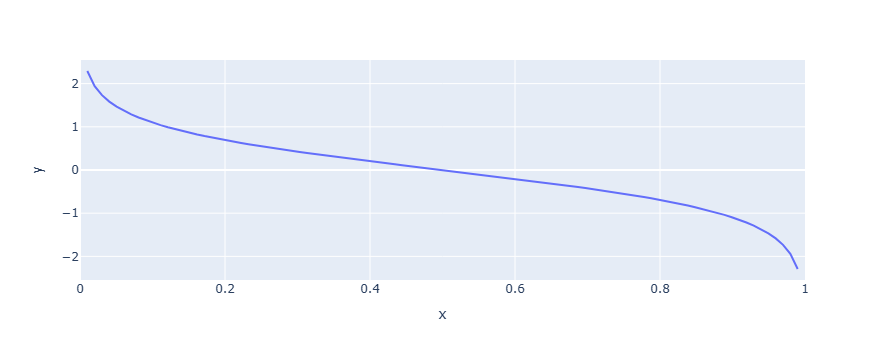

In [3]:
x=np.linspace(0,1,100)

y=0.5*np.log((1-x)/x)

px.line(x=x,y=y)

# custom class

In [43]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

class AdaBoost:
    def __init__(self, n):
        self.n = n
        self.models = []
        self.model_weights = []

    def train(self, X, y):
        n_samples = X.shape[0]
        self.models = [DecisionTreeClassifier(max_depth=1) for _ in range(self.n)]

        y = np.where(y == 0, -1, 1)  # convert to {-1, +1}

        for i in range(self.n):
            row_weights = np.ones(n_samples) / n_samples
            model = self.models[i]
            model.fit(X, y)
            y_pred = model.predict(X)

            error = np.sum(row_weights * (y_pred != y))
            error = max(error, 1e-10)  # to prevent divide-by-zero

            alpha = 0.5 * np.log((1 - error) / error)
            self.model_weights.append(alpha)

            # Update weights
            row_weights *= np.exp(-alpha * y * y_pred)
            row_weights /= np.sum(row_weights)

            # upscaling
            upper_range = np.cumsum(row_weights)
            lower_range = upper_range - row_weights
            rnd_no = np.random.rand(len(upper_range))  
            row_no = []
            
            for rnd in rnd_no:
                for ind in range(len(upper_range)):
                    if rnd < upper_range[ind] and rnd > lower_range[ind]:
                        row_no.append(ind)
                        break
            
            X = np.array([X[ind, :] for ind in row_no])
            y = np.array([y[ind] for ind in row_no])

    def pred(self, X):
        pred = sum(alpha * model.predict(X) for alpha, model in zip(self.model_weights, self.models))
        return np.where(np.sign(pred) == -1, 0, 1)


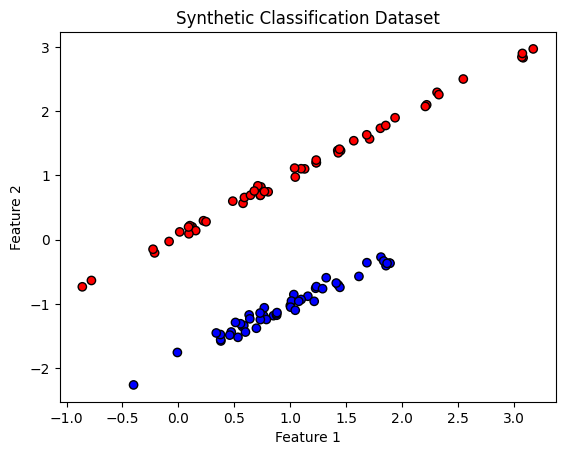

In [16]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")
plt.show()


In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
ad=AdaBoost(5)
ad.train(X_train,y_train)
y_pred=ad.pred(X_test)
y_test

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0])

In [39]:
y_pred

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0])

In [41]:
des=DecisionTreeClassifier(max_depth=1)
des.fit(X_train,y_train)
y_pred=des.predict(X_test)

In [42]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0])

# there is another ada boost algo is used which dont require upsampling

<img src='../../../images/adaboost (1).png'>
<img src='../../../images/adaboost (2).png'>
<img src='../../../images/adaboost (3).png'>
<img src='../../../images/adaboost (4).png'>
<img src='../../../images/adaboost (5).png'>

the weights we provide here to the model is used to calculte gini impurity / entropy

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

class AdaBoost:
    def __init__(self, n):
        self.n = n
        self.models = []
        self.model_weights = []

    def train(self, X, y):
        n_samples = X.shape[0]
        self.models = [DecisionTreeClassifier(max_depth=1) for _ in range(self.n)]

        y = np.where(y == 0, -1, 1)  # convert to {-1, +1}

        row_weights = np.ones(n_samples) / n_samples
        for i in range(self.n):
            model = self.models[i]
            model.fit(X, y, sample_weight=row_weights)
            y_pred = model.predict(X)

            error = np.sum(row_weights * (y_pred != y))
            error = max(error, 1e-10)  # to prevent divide-by-zero

            alpha = 0.5 * np.log((1 - error) / error)
            self.model_weights.append(alpha)

            # Update weights
            row_weights *= np.exp(-alpha * y * y_pred)
            row_weights /= np.sum(row_weights)

           

    def pred(self, X):
        pred = sum(alpha * model.predict(X) for alpha, model in zip(self.model_weights, self.models))
        return np.where(np.sign(pred) == -1, 0, 1)
